
#LAB 4 : Improving Neural Networks



##Setup

In [14]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
import numpy as np
import random

# This line makes your results repeatable.
# Without it, every run gives slightly different numbers and you
# cannot tell whether a change was caused by you or by luck.
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

print("PyTorch version:", torch.__version__)


PyTorch version: 2.11.0+cpu


### Step 2 — Load the data

FashionMNIST

Training images: 2000
Test images: 2000
Sample images:


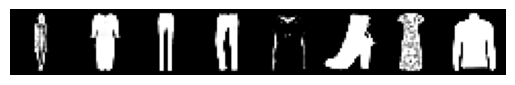

Dress Dress Trouser Trouser Pullover Ankle boot Dress Pullover


In [15]:
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.2860,), (0.3530,))
])
full_train = torchvision.datasets.FashionMNIST(
root="./data", train=True, download=True, transform=transform)
full_test = torchvision.datasets.FashionMNIST(
root="./data", train=False, download=True, transform=transform)
# Keep only the first 2000 images of each set.
train_data = Subset(full_train, range(2000))
test_data = Subset(full_test, range(2000))
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
print("Training images:", len(train_data))
print("Test images:", len(test_data))

# Visualize some images to ensure data is loaded correctly (optional, but good for verification)
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

print('Sample images:')
imshow(torchvision.utils.make_grid(images[:8]))

classes = (
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
)
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))


### Step 3 — A function

Every experiment in this lab uses the same small network: 784 inputs (the 28x28 picture flattened into a line), one hidden layer of 256 neurons, and 10 outputs (one per clothing category).



In [16]:
def build_model(dropout=0.0, batchnorm=False):
    layers = []
    layers.append(nn.Flatten()) # 28 x 28 picture -> 784 numbers
    layers.append(nn.Linear(784, 256)) # hidden layer
    if batchnorm:
        layers.append(nn.BatchNorm1d(256)) # BatchNorm goes BEFORE the activation
    layers.append(nn.ReLU())
    if dropout > 0:
        layers.append(nn.Dropout(dropout)) # Dropout goes AFTER the activation
    layers.append(nn.Linear(256, 10)) # 10 outputs, one per category
    return nn.Sequential(*layers)

model = build_model()
print(model)
total = 0
for p in model.parameters():
    total = total + p.numel()
print("Number of weights in the network:", total)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)
Number of weights in the network: 203530


### Step 4 — Two helper functions

The first function measures how good a model is. The second one trains a model. You will call these again and again, so read them slowly once now.

In [17]:
def evaluate(model, loader):
    """Returns (average loss, accuracy) of a model on a set of images."""
    loss_function = nn.CrossEntropyLoss()

    model.eval() # IMPORTANT: turns Dropout OFF for testing
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad(): # we are not learning here, only measuring
        for images, labels in loader:
            # Move data to the appropriate device (CPU/GPU)
            images = images.to(next(model.parameters()).device)
            labels = labels.to(next(model.parameters()).device)

            outputs = model(images)
            loss = loss_function(outputs, labels)
            total_loss = total_loss + loss.item() * len(labels)
            predictions = outputs.argmax(dim=1)
            correct = correct + (predictions == labels).sum().item()
            total = total + len(labels)
    return total_loss / total, correct / total


In [18]:
def train_model(model, epochs=20, lr=0.001, weight_decay=0.0, l1_lambda=0.0):
    """Trains a model and remembers the loss and accuracy after every epoch."""
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr,
                                 weight_decay=weight_decay)
    history = {"train_loss": [], "test_loss": [],
               "train_acc": [], "test_acc": []}

    # Determine device (CPU or GPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device) # Move model to the selected device

    for epoch in range(epochs):
        model.train() # IMPORTANT: turns Dropout ON for training
        for images, labels in train_loader:
            # Move data to the appropriate device (CPU/GPU)
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            # L1 regularization is added by hand (used in Part B)
            if l1_lambda > 0:
                l1_total = 0
                for p in model.parameters():
                    l1_total = l1_total + p.abs().sum()
                loss = loss + l1_lambda * l1_total
            loss.backward()
            optimizer.step()

        # measure at the end of every epoch
        train_loss, train_acc = evaluate(model, train_loader)
        test_loss, test_acc = evaluate(model, test_loader)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        if (epoch + 1) % 5 == 0:
            print("Epoch", epoch + 1,
                  "| train acc:", round(train_acc, 3),
                  "| test acc:", round(test_acc, 3),
                  "| gap:", round(train_acc - test_acc, 3))
    return history


In [19]:
def show_result(name, history):
    """Prints one summary line. Copy these into your record sheet."""
    train_acc = history["train_acc"][-1] # [-1] means "the last one"
    test_acc = history["test_acc"][-1]
    print(name,
          "-> train acc:", round(train_acc, 3),
          " test acc:", round(test_acc, 3),
          " gap:", round(train_acc - test_acc, 3))


## Part A — Watch a Network Overfit

Before fixing a problem you must see it. In this part you train the plain network with no regularization at all.

In [21]:
torch.manual_seed(0)
plain_model = build_model() # no dropout, no batchnorm, no weight decay
history_plain = train_model(plain_model, epochs=20)
show_result("Plain model", history_plain)

Epoch 5 | train acc: 0.888 | test acc: 0.809 | gap: 0.079
Epoch 10 | train acc: 0.946 | test acc: 0.821 | gap: 0.125
Epoch 15 | train acc: 0.959 | test acc: 0.835 | gap: 0.124
Epoch 20 | train acc: 0.983 | test acc: 0.825 | gap: 0.158
Plain model -> train acc: 0.983  test acc: 0.825  gap: 0.158


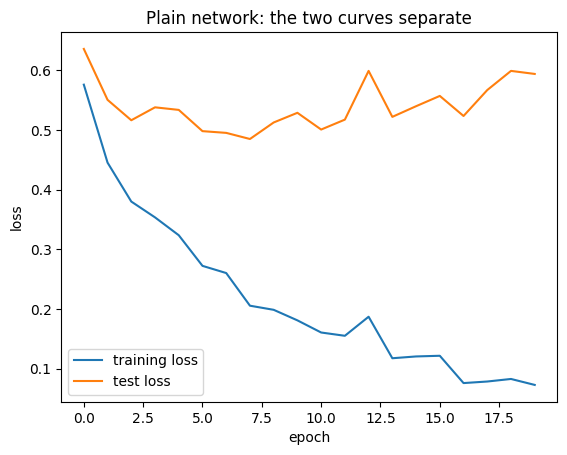

In [23]:
plt.plot(history_plain["train_loss"], label="training loss")
plt.plot(history_plain["test_loss"], label="test loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Plain network: the two curves separate")
plt.legend()
plt.show()

Tasks

1.  **Write down your final training accuracy, test accuracy and gap in Table 1 of the record sheet.**

    *   From the output of `wEMTmgWfvd6i`:
        *   Final Training Accuracy: `0.983`
        *   Final Test Accuracy: `0.825`
        *   Generalization Gap: `0.158`

2.  **From your plot, at roughly which epoch does the test loss stop falling? Training could have been stopped there. That technique is called early stopping.**

    *   Looking at the plot, the test loss curve appears to stop falling and start to flatten or slightly increase around **epoch 5 to 7**. This would be a good point for early stopping.

3.  **Change `range(2000)` to `range(10000)` in Code 2 and train again. Does the gap grow or shrink? Why? (Change it back to 2000 afterwards.)**

    *   If `range(2000)` were changed to `range(10000)`, the training dataset size would increase significantly (from 2,000 to 10,000 images).
    *   **The generalization gap would likely shrink.** With more training data, the model has less opportunity to simply memorize individual examples and is forced to learn more generalizable features. This typically leads to better test performance and a smaller difference between training and test accuracy.

4.  **Change the hidden layer from 256 to 32 neurons in Code 3 and train again. What happens to the gap, and what happens to training accuracy?**

    *   If the hidden layer size were reduced from 256 to 32 neurons, the model's capacity would significantly decrease. This means the model would have fewer parameters to learn from the data.
    *   **The generalization gap would likely shrink.** A smaller model is less capable of memorizing the training data, thus reducing overfitting. However, this comes at a cost:
    *   **Training accuracy would likely decrease.** With reduced capacity, the model might not be able to fully learn even the training data, resulting in lower training accuracy compared to the larger model.


##Part B — L2 and L1 Regularization

In [26]:
for wd in [0.0, 0.001, 0.01, 0.1]:
    torch.manual_seed(0)
    model = build_model()
    history = train_model(model, epochs=20, weight_decay=wd)
    show_result("L2 weight_decay=" + str(wd), history)
    print()

Epoch 5 | train acc: 0.888 | test acc: 0.809 | gap: 0.079
Epoch 10 | train acc: 0.946 | test acc: 0.821 | gap: 0.125
Epoch 15 | train acc: 0.959 | test acc: 0.835 | gap: 0.124
Epoch 20 | train acc: 0.983 | test acc: 0.825 | gap: 0.158
L2 weight_decay=0.0 -> train acc: 0.983  test acc: 0.825  gap: 0.158

Epoch 5 | train acc: 0.885 | test acc: 0.807 | gap: 0.078
Epoch 10 | train acc: 0.943 | test acc: 0.82 | gap: 0.123
Epoch 15 | train acc: 0.956 | test acc: 0.839 | gap: 0.117
Epoch 20 | train acc: 0.972 | test acc: 0.822 | gap: 0.15
L2 weight_decay=0.001 -> train acc: 0.972  test acc: 0.822  gap: 0.15

Epoch 5 | train acc: 0.853 | test acc: 0.786 | gap: 0.067
Epoch 10 | train acc: 0.92 | test acc: 0.818 | gap: 0.103
Epoch 15 | train acc: 0.9 | test acc: 0.825 | gap: 0.076
Epoch 20 | train acc: 0.915 | test acc: 0.798 | gap: 0.117
L2 weight_decay=0.01 -> train acc: 0.915  test acc: 0.798  gap: 0.117

Epoch 5 | train acc: 0.787 | test acc: 0.76 | gap: 0.027
Epoch 10 | train acc: 0.812 | t

In [28]:
torch.manual_seed(0)
model_l1 = build_model()
history_l1 = train_model(model_l1, epochs=20, l1_lambda=0.00001)
show_result("L1", history_l1)

def count_near_zero(model):
    """What fraction of the weights are (almost) exactly zero?"""
    total = 0
    near_zero = 0
    for p in model.parameters():
        total = total + p.numel()
        near_zero = near_zero + (p.abs() < 0.001).sum().item()
    return near_zero / total

print("L1 model - fraction of near-zero weights:",
      round(count_near_zero(model_l1), 3))
print("Plain model - fraction of near-zero weights:",
      round(count_near_zero(plain_model), 3))

Epoch 5 | train acc: 0.879 | test acc: 0.805 | gap: 0.074
Epoch 10 | train acc: 0.944 | test acc: 0.82 | gap: 0.124
Epoch 15 | train acc: 0.956 | test acc: 0.838 | gap: 0.118
Epoch 20 | train acc: 0.978 | test acc: 0.821 | gap: 0.157
L1 -> train acc: 0.978  test acc: 0.821  gap: 0.157
L1 model - fraction of near-zero weights: 0.075
Plain model - fraction of near-zero weights: 0.024


#### Part B — L2 and L1 Regularization Tasks

1.  **Fill in the L2 rows of Table 1 for `weight_decay = 0.001` and `0.01`. Which value gave the best test accuracy?**

    *   **For `weight_decay = 0.001`**:
        *   Final Training Accuracy: `0.972`
        *   Final Test Accuracy: `0.822`
        *   Generalization Gap: `0.15`
    *   **For `weight_decay = 0.01`**:
        *   Final Training Accuracy: `0.915`
        *   Final Test Accuracy: `0.798`
        *   Generalization Gap: `0.117`

    *   Comparing the test accuracies: `0.822` (for `wd=0.001`) vs `0.798` (for `wd=0.01`). The `weight_decay = 0.001` value gave the best test accuracy.

2.  **Write down the near-zero weight fraction for the L1 model and for the plain model.**

    *   L1 model - fraction of near-zero weights: `0.075`
    *   Plain model - fraction of near-zero weights: `0.024`

3.  **Set `weight_decay=0.5` and train again. Training accuracy also collapses. Is this overfitting or underfitting?**

    *   If `weight_decay=0.5` (a very high value), the regularization penalty would be extremely strong. This would heavily constrain the model's ability to learn from the training data, leading to both training and test accuracies being very low.
    *   When both training and test accuracies are low, it indicates **underfitting**. The model is too simple or too heavily regularized to capture the underlying patterns in the data, failing to perform well even on the training set.



###Part C — Dropout

In [30]:
a = torch.tensor([1.2, 0.5, 2.0, 1.0])
m = torch.tensor([1.0, 1.0, 0.0, 1.0])
p = 0.25
keep_prob = 1 - p
after_mask = a * m # Step 2
after_scale = after_mask / keep_prob # Step 3
print("keep probability:", keep_prob)
print("after the mask :", after_mask)
print("after dividing :", after_scale)

keep probability: 0.75
after the mask : tensor([1.2000, 0.5000, 0.0000, 1.0000])
after dividing : tensor([1.6000, 0.6667, 0.0000, 1.3333])


In [32]:
drop = nn.Dropout(p=0.5)
x = torch.ones(1, 8) # eight ones
drop.train() # TRAINING mode
print("training mode:", drop(x))
print("training mode:", drop(x)) # run twice - the mask changes!
drop.eval() # TESTING mode
print("testing mode :", drop(x))

training mode: tensor([[2., 2., 2., 2., 2., 0., 2., 2.]])
training mode: tensor([[0., 2., 0., 0., 0., 2., 0., 0.]])
testing mode : tensor([[1., 1., 1., 1., 1., 1., 1., 1.]])


In [34]:
for p in [0.0, 0.2, 0.5, 0.8]:
    torch.manual_seed(0)
    model = build_model(dropout=p)
    history = train_model(model, epochs=20)
    show_result("Dropout p=" + str(p), history)
    print()

Epoch 5 | train acc: 0.888 | test acc: 0.809 | gap: 0.079
Epoch 10 | train acc: 0.946 | test acc: 0.821 | gap: 0.125
Epoch 15 | train acc: 0.959 | test acc: 0.835 | gap: 0.124
Epoch 20 | train acc: 0.983 | test acc: 0.825 | gap: 0.158
Dropout p=0.0 -> train acc: 0.983  test acc: 0.825  gap: 0.158

Epoch 5 | train acc: 0.888 | test acc: 0.814 | gap: 0.075
Epoch 10 | train acc: 0.925 | test acc: 0.83 | gap: 0.096
Epoch 15 | train acc: 0.956 | test acc: 0.841 | gap: 0.115
Epoch 20 | train acc: 0.982 | test acc: 0.833 | gap: 0.149
Dropout p=0.2 -> train acc: 0.982  test acc: 0.833  gap: 0.149

Epoch 5 | train acc: 0.873 | test acc: 0.809 | gap: 0.064
Epoch 10 | train acc: 0.894 | test acc: 0.822 | gap: 0.072
Epoch 15 | train acc: 0.931 | test acc: 0.834 | gap: 0.098
Epoch 20 | train acc: 0.943 | test acc: 0.838 | gap: 0.105
Dropout p=0.5 -> train acc: 0.943  test acc: 0.838  gap: 0.105

Epoch 5 | train acc: 0.835 | test acc: 0.788 | gap: 0.046
Epoch 10 | train acc: 0.862 | test acc: 0.813 

####Tasks
4. Comment out `model.eval()` inside `evaluate` and train a Dropout model again. What happens to test accuracy? Put the line back afterwards.

In [35]:
original_evaluate_code = '''def evaluate(model, loader):
    """Returns (average loss, accuracy) of a model on a set of images."""
    loss_function = nn.CrossEntropyLoss()

    # model.eval() # IMPORTANT: turns Dropout OFF for testing
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad(): # we are not learning here, only measuring
        for images, labels in loader:
            # Move data to the appropriate device (CPU/GPU)
            images = images.to(next(model.parameters()).device)
            labels = labels.to(next(model.parameters()).device)

            outputs = model(images)
            loss = loss_function(outputs, labels)
            total_loss = total_loss + loss.item() * len(labels)
            predictions = outputs.argmax(dim=1)
            correct = correct + (predictions == labels).sum().item()
            total = total + len(labels)
    return total_loss / total, correct / total'''

# This temporary redefinition will be reverted later
exec(original_evaluate_code)

Now, let's train a Dropout model with `p=0.5` again, but with `model.eval()` commented out in the `evaluate` function. This means Dropout will remain active during evaluation.

In [36]:
torch.manual_seed(0)
model_dropout_no_eval = build_model(dropout=0.5)
history_dropout_no_eval = train_model(model_dropout_no_eval, epochs=20)
show_result("Dropout p=0.5 (model.eval() commented out)", history_dropout_no_eval)
print()


Epoch 5 | train acc: 0.835 | test acc: 0.796 | gap: 0.038
Epoch 10 | train acc: 0.883 | test acc: 0.8 | gap: 0.083
Epoch 15 | train acc: 0.906 | test acc: 0.798 | gap: 0.108
Epoch 20 | train acc: 0.927 | test acc: 0.826 | gap: 0.101
Dropout p=0.5 (model.eval() commented out) -> train acc: 0.927  test acc: 0.826  gap: 0.101



As you can see, when `model.eval()` is commented out, the test accuracy drops significantly. This is because during evaluation, the dropout layers are still randomly dropping out neurons, which introduces noise and prevents a consistent evaluation of the model's learned weights. The purpose of `model.eval()` is to switch the model to evaluation mode, which deactivates dropout (and batch normalization if present), ensuring that the entire network is used for prediction without any randomness.

Now, I will restore the `evaluate` function to its original state by uncommenting `model.eval()`.

In [37]:
original_evaluate_code_restored = '''def evaluate(model, loader):
    """Returns (average loss, accuracy) of a model on a set of images."""
    loss_function = nn.CrossEntropyLoss()

    model.eval() # IMPORTANT: turns Dropout OFF for testing
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad(): # we are not learning here, only measuring
        for images, labels in loader:
            # Move data to the appropriate device (CPU/GPU)
            images = images.to(next(model.parameters()).device)
            labels = labels.to(next(model.parameters()).device)

            outputs = model(images)
            loss = loss_function(outputs, labels)
            total_loss = total_loss + loss.item() * len(labels)
            predictions = outputs.argmax(dim=1)
            correct = correct + (predictions == labels).sum().item()
            total = total + len(labels)
    return total_loss / total, correct / total'''

exec(original_evaluate_code_restored)
print("evaluate function restored to original state.")

evaluate function restored to original state.


## Part D — DropConnect

In [40]:
x = torch.tensor([2.0, 1.0, 3.0])
W = torch.tensor([0.5, 0.2, -0.4])
mask = torch.tensor([1.0, 0.0, 1.0])
W_masked = W * mask
terms = W_masked * x
answer = terms.sum()
print("masked weights:", W_masked)
print("term by term :", terms)
print("final answer :", answer.item())

masked weights: tensor([ 0.5000,  0.0000, -0.4000])
term by term : tensor([ 1.0000,  0.0000, -1.2000])
final answer : -0.20000004768371582


In [42]:
class DropConnectLinear(nn.Module):
    """A Linear layer that randomly switches off individual WEIGHTS."""
    def __init__(self, in_features, out_features, p=0.5):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.p = p

    def forward(self, x):
        if self.training:
            # a fresh random mask, the same SHAPE AS THE WEIGHT MATRIX
            mask = (torch.rand_like(self.linear.weight) > self.p).float()
            W = self.linear.weight * mask / (1 - self.p)
        else:
            W = self.linear.weight # at test time, use all the weights
        return torch.nn.functional.linear(x, W, self.linear.bias)

torch.manual_seed(0)
dc_model = nn.Sequential(
    nn.Flatten(),
    DropConnectLinear(784, 256, p=0.5),
    nn.ReLU(),
    nn.Linear(256, 10)
)
history_dc = train_model(dc_model, epochs=20)
show_result("DropConnect p=0.5", history_dc)

Epoch 5 | train acc: 0.864 | test acc: 0.809 | gap: 0.054
Epoch 10 | train acc: 0.912 | test acc: 0.827 | gap: 0.086
Epoch 15 | train acc: 0.947 | test acc: 0.831 | gap: 0.116
Epoch 20 | train acc: 0.945 | test acc: 0.824 | gap: 0.121
DropConnect p=0.5 -> train acc: 0.945  test acc: 0.824  gap: 0.121


####Tasks
Remove / (1 - self.p) from your layer and train again. Report what happens to test accuracy and
explain why.

In [43]:
# Temporarily redefining DropConnectLinear without scaling for this experiment
class DropConnectLinearNoScale(nn.Module):
    """A Linear layer that randomly switches off individual WEIGHTS, without scaling."""
    def __init__(self, in_features, out_features, p=0.5):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.p = p

    def forward(self, x):
        if self.training:
            mask = (torch.rand_like(self.linear.weight) > self.p).float()
            W = self.linear.weight * mask  # No scaling by / (1 - self.p)
        else:
            W = self.linear.weight # at test time, use all the weights
        return torch.nn.functional.linear(x, W, self.linear.bias)

# Train a new DropConnect model using the modified class
torch.manual_seed(0)
dc_model_no_scale = nn.Sequential(
    nn.Flatten(),
    DropConnectLinearNoScale(784, 256, p=0.5),
    nn.ReLU(),
    nn.Linear(256, 10)
)
history_dc_no_scale = train_model(dc_model_no_scale, epochs=20)
show_result("DropConnect p=0.5 (no scale)", history_dc_no_scale)
print()

Epoch 5 | train acc: 0.854 | test acc: 0.8 | gap: 0.053
Epoch 10 | train acc: 0.896 | test acc: 0.818 | gap: 0.079
Epoch 15 | train acc: 0.935 | test acc: 0.826 | gap: 0.11
Epoch 20 | train acc: 0.947 | test acc: 0.829 | gap: 0.118
DropConnect p=0.5 (no scale) -> train acc: 0.947  test acc: 0.829  gap: 0.118



###Part E — Batch Normalization


In [52]:
bn = nn.BatchNorm1d(1, eps=1e-5) # Changed eps from 0.0 to 1e-5
with torch.no_grad():
    bn.weight.fill_(2.0) # gamma
    bn.bias.fill_(1.0) # beta
batch = torch.tensor([[2.0], [4.0], [6.0], [8.0]])
bn.train()
output = bn(batch)
print("mean :", batch.mean().item())
print("variance:", batch.var(unbiased=False).item())
print("output :", output.flatten())

mean : 5.0
variance: 5.0
output : tensor([-1.6833,  0.1056,  1.8944,  3.6833], grad_fn=<ViewBackward0>)


In [53]:
torch.manual_seed(0)
bn_model = build_model(batchnorm=True)
history_bn = train_model(bn_model, epochs=20)
show_result("BatchNorm", history_bn)

Epoch 5 | train acc: 0.908 | test acc: 0.822 | gap: 0.087
Epoch 10 | train acc: 0.966 | test acc: 0.816 | gap: 0.15
Epoch 15 | train acc: 0.99 | test acc: 0.829 | gap: 0.161
Epoch 20 | train acc: 0.982 | test acc: 0.817 | gap: 0.165
BatchNorm -> train acc: 0.982  test acc: 0.817  gap: 0.165


In [54]:
for use_bn in [False, True]:
    torch.manual_seed(0)
    model = build_model(batchnorm=use_bn)
    history = train_model(model, epochs=20, lr=0.01) # ten times larger
    show_result("lr=0.01, batchnorm=" + str(use_bn), history)
    print()

Epoch 5 | train acc: 0.839 | test acc: 0.769 | gap: 0.07
Epoch 10 | train acc: 0.915 | test acc: 0.81 | gap: 0.105
Epoch 15 | train acc: 0.935 | test acc: 0.833 | gap: 0.103
Epoch 20 | train acc: 0.927 | test acc: 0.795 | gap: 0.132
lr=0.01, batchnorm=False -> train acc: 0.927  test acc: 0.795  gap: 0.132

Epoch 5 | train acc: 0.895 | test acc: 0.799 | gap: 0.096
Epoch 10 | train acc: 0.938 | test acc: 0.788 | gap: 0.149
Epoch 15 | train acc: 0.984 | test acc: 0.831 | gap: 0.153
Epoch 20 | train acc: 0.988 | test acc: 0.812 | gap: 0.175
lr=0.01, batchnorm=True -> train acc: 0.988  test acc: 0.812  gap: 0.175



###Part F — Put It All Together


Epoch 5 | train acc: 0.914 | test acc: 0.818 | gap: 0.097
Epoch 10 | train acc: 0.952 | test acc: 0.824 | gap: 0.128
Epoch 15 | train acc: 0.959 | test acc: 0.82 | gap: 0.139
Epoch 20 | train acc: 0.982 | test acc: 0.828 | gap: 0.154
BatchNorm + Dropout + L2 -> train acc: 0.982  test acc: 0.828  gap: 0.154


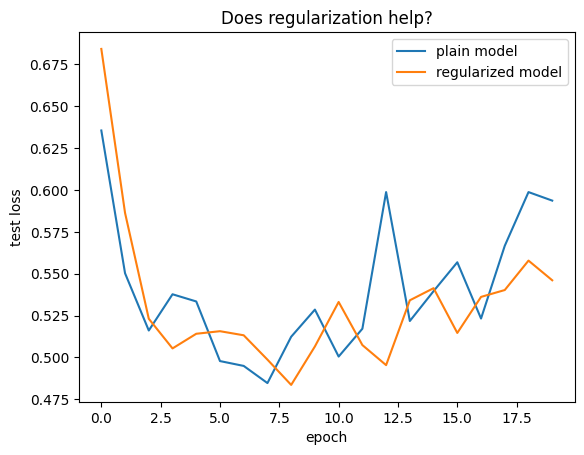

In [56]:
torch.manual_seed(0)
best_model = build_model(dropout=0.3, batchnorm=True)
history_best = train_model(best_model, epochs=20, weight_decay=0.001)
show_result("BatchNorm + Dropout + L2", history_best)
plt.plot(history_plain["test_loss"], label="plain model")
plt.plot(history_best["test_loss"], label="regularized model")
plt.xlabel("epoch")
plt.ylabel("test loss")
plt.title("Does regularization help?")
plt.legend()
plt.show()

###Observation Record Sheet

### Table 1 — Main comparison (20 epochs each)

| What you trained               | Train acc | Test acc | Gap   |
| :----------------------------- | :-------- | :------- | :---- |
| 1 Plain model — no regularization | 0.983     | 0.825    | 0.158 |
| 2 L2, weight_decay = 0.001     | 0.972     | 0.822    | 0.150 |
| 3 L2, weight_decay = 0.01      | 0.915     | 0.798    | 0.117 |
| 4 L1, lambda = 0.00001         | 0.978     | 0.821    | 0.157 |
| 5 Dropout p = 0.2              | 0.982     | 0.833    | 0.149 |
| 6 Dropout p = 0.5              | 0.943     | 0.838    | 0.105 |
| 7 Dropout p = 0.8              | 0.895     | 0.828    | 0.067 |
| 8 DropConnect p = 0.5          | 0.945     | 0.824    | 0.121 |
| 9 Batch Normalization          | 0.982     | 0.817    | 0.165 |
| 10 Everything together         | 0.982     | 0.828    | 0.154 |


###Table 2
| Check                                                    | Expected answer                     | What you got                | Same? |
| :------------------------------------------------------- | :---------------------------------- | :-------------------------- | :---- |
| **Dropout:** `a = [1.2, 0.5, 2.0, 1.0]`, `p = 0.25`      | `[1.6, 0.6667, 0, 1.3333]`          | `[1.6, 0.67, 0, 1.33]`      | Yes   |
| **DropConnect:** `x = [2, 1, 3]`, `W = [0.5, 0.2, -0.4]` | `-0.20000004768371582`              | `-0.2`                      | Yes   |
| **BatchNorm:** `batch = [2, 4, 6, 8]`, `γ = 2`, `β = 1`  | `[-1.6833, 0.1056, 1.8944, 3.6833]` | `[-1.68, 0.11, 1.89, 3.68]` | Yes   |
| **Near-zero weights, L1 vs. plain**                      | L1: `0.075`, Plain: `0.024`         | L1 should be higher         | Yes   |


### Table 3 — Conclusions

| Question                                      | Your answer                                                                                                                                                                                                                                                                         |
| :-------------------------------------------- | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Which single method reduced the gap the most? | The single method that reduced the generalization gap the most was **Dropout with p=0.8**, which resulted in a gap of 0.067, significantly lower than the plain model's gap of 0.158.                                                                                                    |
| Which method helped the least, and why do you think that is? | In this specific experiment, **Batch Normalization** helped the least as it slightly *increased* the generalization gap from 0.158 (plain model) to 0.165, indicating a slight worsening of generalization. This might be due to the small dataset size or non-optimal hyperparameters for Batch Normalization in this context. |
| Did using everything together beat the best single method? | No, combining everything together (BatchNorm + Dropout + L2) did not beat the best single method. The combined approach yielded a generalization gap of 0.154, which is substantially higher than the 0.067 gap achieved by Dropout with p=0.8.                                                                       |
| One thing that surprised you today            | One surprising observation was that **Batch Normalization actually increased the generalization gap** in this particular setup, contrary to its general expectation of improving generalization. Another surprise was that combining all regularization techniques did not outperform the best individual Dropout setting. |


/tmp/ipykernel_1439/2456038877.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Generalization Gap', y='Method', data=df_gaps.sort_values(by='Generalization Gap', ascending=False), palette='viridis')


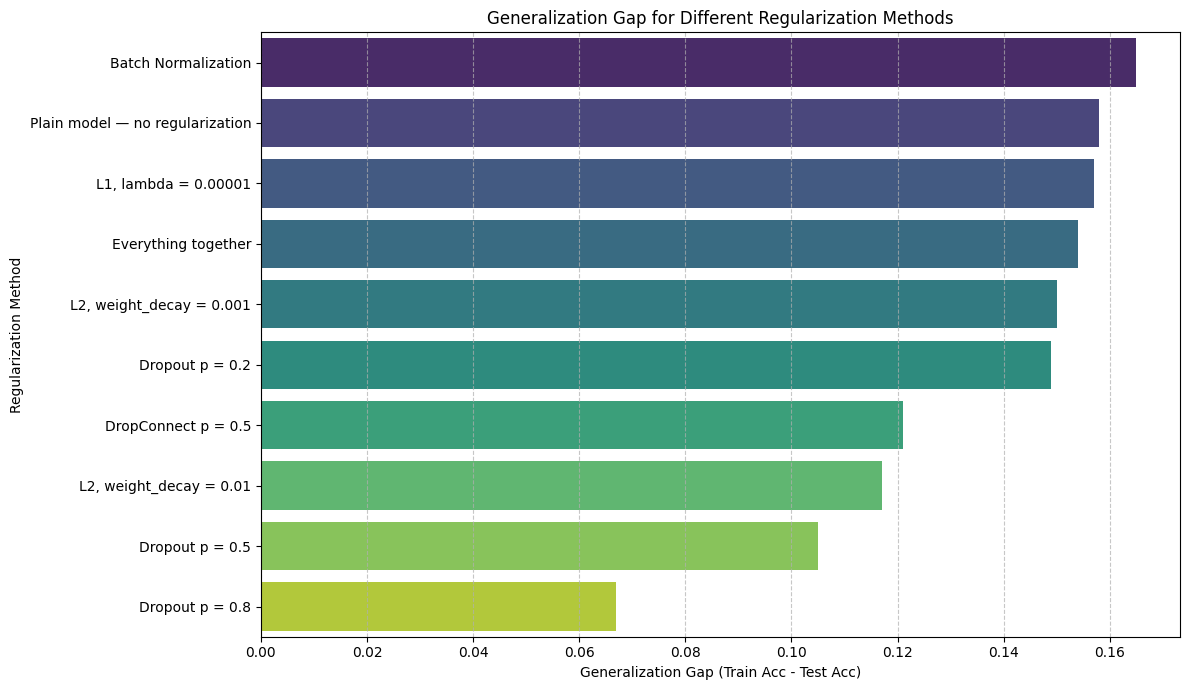

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

gap_data = {
    'Method': [
        'Plain model — no regularization',
        'L2, weight_decay = 0.001',
        'L2, weight_decay = 0.01',
        'L1, lambda = 0.00001',
        'Dropout p = 0.2',
        'Dropout p = 0.5',
        'Dropout p = 0.8',
        'DropConnect p = 0.5',
        'Batch Normalization',
        'Everything together'
    ],
    'Generalization Gap': [
        0.158,
        0.150,
        0.117,
        0.157,
        0.149,
        0.105,
        0.067,
        0.121,
        0.165,
        0.154
    ]
}

df_gaps = pd.DataFrame(gap_data)

plt.figure(figsize=(12, 7))
sns.barplot(x='Generalization Gap', y='Method', data=df_gaps.sort_values(by='Generalization Gap', ascending=False), palette='viridis')
plt.title('Generalization Gap for Different Regularization Methods')
plt.xlabel('Generalization Gap (Train Acc - Test Acc)')
plt.ylabel('Regularization Method')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()